# Pemodelan Konsumsi Bahan Bakar Kendaraan Menggunakan Regresi Linear Berganda dengan One-Hot Encoding

**Info Ngopi**

| Anggota | NIM |
|---|---|
| Amadeus Eugene Dirgantara | 0706012410063 |
| Rei Putra Soemanto | 0706012410060 |
| Jason Tio | 0706012410006 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'plotly_mimetype+notebook'
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
sns.set_theme(style='whitegrid', context='notebook')
RNG = 1

## Fase 1: Eksplorasi Data dan Pra-pemrosesan

### 1. Memuat Data Mentah

In [2]:
raw = pd.read_csv('dataset/Fuel_Consumption_2000-2022.csv')
print('Bentuk:', raw.shape)
raw.head()

Bentuk: (22556, 13)


,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6000,4,A4,X,9.2000,6.7000,8.1000,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6000,4,M5,X,8.5000,6.5000,7.6000,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2000,6,AS5,Z,12.2000,7.4000,10.0000,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5000,6,A4,Z,13.4000,9.2000,11.5000,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8000,4,A4,X,10.0000,7.0000,8.6000,33,198


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              22556 non-null  int64  
 1   MAKE              22556 non-null  object 
 2   MODEL             22556 non-null  object 
 3   VEHICLE CLASS     22556 non-null  object 
 4   ENGINE SIZE       22556 non-null  float64
 5   CYLINDERS         22556 non-null  int64  
 6   TRANSMISSION      22556 non-null  object 
 7   FUEL              22556 non-null  object 
 8   FUEL CONSUMPTION  22556 non-null  float64
 9   HWY (L/100 km)    22556 non-null  float64
 10  COMB (L/100 km)   22556 non-null  float64
 11  COMB (mpg)        22556 non-null  int64  
 12  EMISSIONS         22556 non-null  int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 2.2+ MB


Dataset memuat 22.556 baris kendaraan dari tahun model 2000 sampai 2022. Kolom terbagi menjadi numerik (ukuran mesin, jumlah silinder, beberapa metrik `comb_l_100km`, emisi) dan kategorikal bertipe object (merek, kelas kendaraan, transmisi, jenis bahan bakar).

### 2. Memeriksa Nilai yang Hilang

In [4]:
missing = raw.isna().sum().to_frame('n_missing')
missing

,n_missing
YEAR,0
MAKE,0
MODEL,0
VEHICLE CLASS,0
ENGINE SIZE,0
CYLINDERS,0
TRANSMISSION,0
FUEL,0
FUEL CONSUMPTION,0
HWY (L/100 km),0


Tidak ada nilai yang hilang pada kolom mana pun, sehingga tidak diperlukan imputasi.

### 3. Memeriksa Data Duplikat

In [5]:
n_before = len(raw)
raw = raw.drop_duplicates().reset_index(drop=True)
print(f'Menghapus {n_before - len(raw)} baris duplikat. Tersisa: {len(raw)}')

Menghapus 1 baris duplikat. Tersisa: 22555


Satu baris duplikat persis dihapus agar setiap baris merepresentasikan satu observasi unik.

### 4. Identifikasi Variabel Numerik dan Kategorikal

Sebelum membangun model, kita memetakan peran tiap kolom: mana prediktor numerik kontinu dan mana prediktor kategorikal yang akan di-one-hot, beserta jumlah nilai uniknya.

In [6]:
ringkasan = raw.dtypes.to_frame('dtype')
ringkasan['n_unique'] = raw.nunique()
ringkasan

,dtype,n_unique
YEAR,int64,23
MAKE,object,87
MODEL,object,4242
VEHICLE CLASS,object,32
ENGINE SIZE,float64,63
CYLINDERS,int64,9
TRANSMISSION,object,30
FUEL,object,5
FUEL CONSUMPTION,float64,228
HWY (L/100 km),float64,152


**Penetapan peran tiap kolom**:
- Prediktor numerik: `engine_size`, `cylinders`, `year`.
- Prediktor kategorikal: `fuel` (5), `vehicle_class` (32), `transmission` (30).

In [7]:
for col in ['FUEL', 'VEHICLE CLASS', 'TRANSMISSION']:
    vals = sorted(raw[col].unique())
    print(f'{col} ({len(vals)} nilai unik):')
    print(' ', vals)
    print()

FUEL (5 nilai unik):
  ['D', 'E', 'N', 'X', 'Z']

VEHICLE CLASS (32 nilai unik):
  ['COMPACT', 'Compact', 'FULL-SIZE', 'Full-size', 'MID-SIZE', 'MINICOMPACT', 'MINIVAN', 'Mid-size', 'Minicompact', 'Minivan', 'PICKUP TRUCK - SMALL', 'PICKUP TRUCK - STANDARD', 'Pickup truck: Small', 'Pickup truck: Standard', 'SPECIAL PURPOSE VEHICLE', 'STATION WAGON - MID-SIZE', 'STATION WAGON - SMALL', 'SUBCOMPACT', 'SUV', 'SUV - SMALL', 'SUV - STANDARD', 'SUV: Small', 'SUV: Standard', 'Special purpose vehicle', 'Station wagon: Mid-size', 'Station wagon: Small', 'Subcompact', 'TWO-SEATER', 'Two-seater', 'VAN - CARGO', 'VAN - PASSENGER', 'Van: Passenger']

TRANSMISSION (30 nilai unik):
  ['A10', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'AM5', 'AM6', 'AM7', 'AM8', 'AM9', 'AS10', 'AS4', 'AS5', 'AS6', 'AS7', 'AS8', 'AS9', 'AV', 'AV1', 'AV10', 'AV6', 'AV7', 'AV8', 'M4', 'M5', 'M6', 'M7']



**Observasi nilai kategori (sebelum normalisasi)**:
- `FUEL` berisi 5 kode (D, E, N, X, Z) yang akan diterjemahkan menjadi nama yang mudah dibaca.
- `VEHICLE CLASS` memuat label yang sama dengan format berbeda, baik kapitalisasi maupun pemisah (` - ` vs `: `), misalnya `SUV - SMALL` dan `SUV: Small`. Keduanya perlu disamakan agar tidak terhitung sebagai kelas berbeda.
- `TRANSMISSION` menggabungkan tipe (A, AM, AS, AV, M) dan jumlah gigi (3 sampai 10) dalam satu kode, sehingga akan dipisah menjadi dua fitur: tipe dan jumlah gigi. Pengecualian untuk "AV" yang merupakan *continuously variable transmission* dimana rasio giginya kontinu, bukan bilangan bulat, sehingga tidak memiliki jumlah gigi yang terdefinisi dan diberi nilai 0.

### 5. Membangun Frame Analisis

In [8]:
df = raw[['ENGINE SIZE', 'CYLINDERS', 'YEAR', 'FUEL', 'VEHICLE CLASS', 'TRANSMISSION', 'COMB (L/100 km)']].rename(
    columns={
        'ENGINE SIZE': 'engine_size',
        'CYLINDERS': 'cylinders',
        'YEAR': 'year',
        'FUEL': 'fuel',
        'VEHICLE CLASS': 'vehicle_class',
        'TRANSMISSION': 'transmission',
        'COMB (L/100 km)': 'comb_l_100km',
    }
).reset_index(drop=True)

# Samakan kapitalisasi DAN pemisah kelas kendaraan (' - ' vs ': ')
df['vehicle_class'] = (df['vehicle_class'].str.upper()
                       .str.replace(r'\s*[-:]\s*', ' ', regex=True).str.strip())

# Terjemahkan kode bahan bakar sesuai definisi di dataset
fuel_names = {'X': 'Regular gasoline', 'Z': 'Premium gasoline', 'D': 'Diesel',
              'E': 'Ethanol (E85)', 'N': 'Natural Gas'}
df['fuel'] = df['fuel'].str.upper().str.strip().map(fuel_names)

# Pisahkan transmisi menjadi tipe (A/AM/AS/AV/M) dan jumlah gigi.
# CVT (AV) continuously variable, tidak punya gigi tetap -> n_gears = 0;
df['transmission_type'] = df['transmission'].str.extract(r'^([A-Z]+)')
gears = df['transmission'].str.extract(r'(\d+)')[0].astype(float)
df['n_gears'] = gears.where(df['transmission_type'] != 'AV', other=0).fillna(0).astype(int)
df = df.drop(columns='transmission')

num_cols = ['engine_size', 'cylinders', 'year', 'n_gears']
cat_cols = ['fuel', 'vehicle_class', 'transmission_type']
target = 'comb_l_100km'

print('Kategori tiap prediktor kategorikal:')
for col in cat_cols:
    print(f'  {col:18s}: {df[col].nunique()}')
print('n_gears unik:', sorted(df['n_gears'].unique()))
df.head()

Kategori tiap prediktor kategorikal:
  fuel              : 5
  vehicle_class     : 17
  transmission_type : 5
n_gears unik: [0, 3, 4, 5, 6, 7, 8, 9, 10]


,engine_size,cylinders,year,fuel,vehicle_class,comb_l_100km,transmission_type,n_gears
0,1.6000,4,2000,Regular gasoline,COMPACT,8.1000,A,4
1,1.6000,4,2000,Regular gasoline,COMPACT,7.6000,M,5
2,3.2000,6,2000,Premium gasoline,MID SIZE,10.0000,AS,5
3,3.5000,6,2000,Premium gasoline,MID SIZE,11.5000,A,4
4,1.8000,4,2000,Regular gasoline,SUBCOMPACT,8.6000,A,4


- Prediktor numerik: `engine_size`, `cylinders`, `year`, dan `n_gears` (dari pemisahan transmisi).
- Prediktor kategorikal: `fuel`, `vehicle_class`, dan `transmission_type`.
- Kode bahan bakar diterjemahkan menjadi nama yang mudah dibaca.
- `vehicle_class` disamakan kapitalisasi dan pemisahnya (contoh: "SUV - SMALL" dan "SUV: Small" disamakan jadi "SUV SMALL"). Setelah dirapikan, jumlah kelas menyusut dari 32 menjadi 17.
- `transmission` dipisah menjadi `transmission_type` (A/AM/AS/AV/M) dan `n_gears`. CVT (tipe AV) tidak memiliki gigi tetap, sehingga `n_gears = 0`.

### 6. Statistik Deskriptif

In [9]:
df[num_cols + [target]].describe().T

,count,mean,std,min,25%,50%,75%,max
engine_size,22555.0000,3.3566,1.3354,0.8000,2.3000,3.0000,4.2000,8.4000
cylinders,22555.0000,5.8540,1.8196,2.0000,4.0000,6.0000,8.0000,16.0000
year,22555.0000,2011.5550,6.2979,2000.0000,2006.0000,2012.0000,2017.0000,2022.0000
n_gears,22555.0000,5.6354,1.9566,0.0000,5.0000,6.0000,6.0000,10.0000
comb_l_100km,22555.0000,11.0341,2.9108,3.6000,9.1000,10.6000,12.7000,26.1000


In [10]:
for col in cat_cols:
    print(f'== {col} ({df[col].nunique()} kategori) ==')
    print(df[col].value_counts().head(6).to_string())
    print()

== fuel (5 kategori) ==
fuel
Regular gasoline    11822
Premium gasoline     9315
Ethanol (E85)        1071
Diesel                314
Natural Gas            33

== vehicle_class (17 kategori) ==
vehicle_class
COMPACT                  3127
MID SIZE                 2960
SUV                      2639
PICKUP TRUCK STANDARD    2204
SUBCOMPACT               2010
SUV SMALL                1756

== transmission_type (5 kategori) ==
transmission_type
A     8690
AS    6736
M     4844
AV    1207
AM    1078



**Ringkasan distribusi**:
- Ukuran mesin berkisar ~1 sampai 8 L, silinder terpusat di 4/6/8, tahun tersebar merata 2000 sampai 2022, dan jumlah gigi berkisar 0 (CVT) sampai 10.
- Jenis bahan bakar didominasi Regular gasoline dan Premium gasoline. tipe transmisi tersebar pada lima kategori (otomatis, manual, dan variannya).

### 7. Distribusi `comb_l_100km` per Kategori

Sebelum melakukan one-hot encoding, kita memeriksa apakah setiap variabel kategorikal benar-benar memiliki dampak terhadap nilai `comb_l_100km`. Jika terdapat pergeseran median `comb_l_100km` antar kategori, maka variabel itu benar-benar mengandung informasi yang layak dipertimbangkan dalam model. 

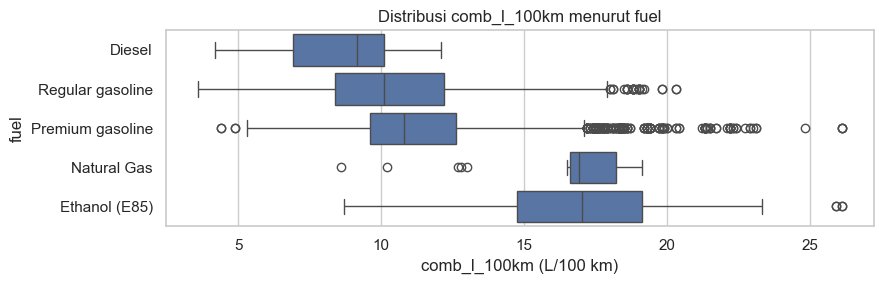

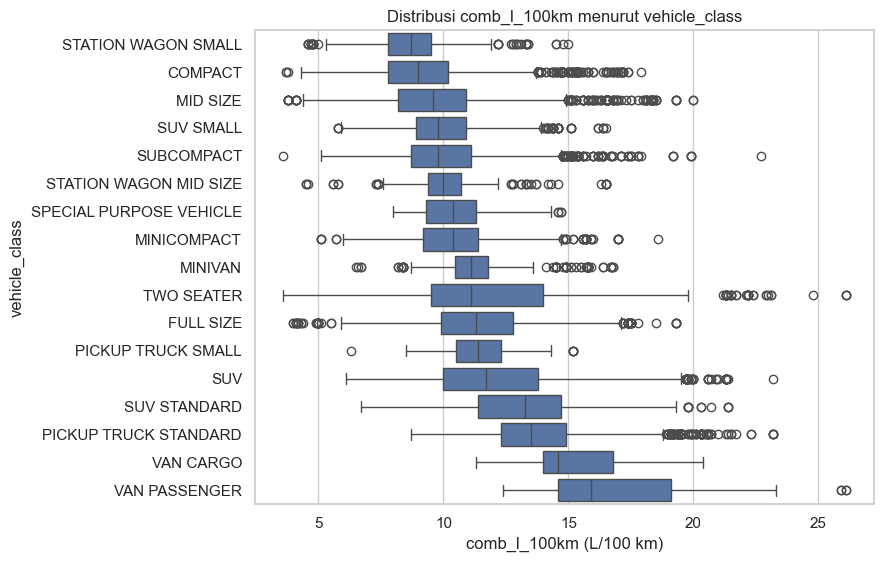

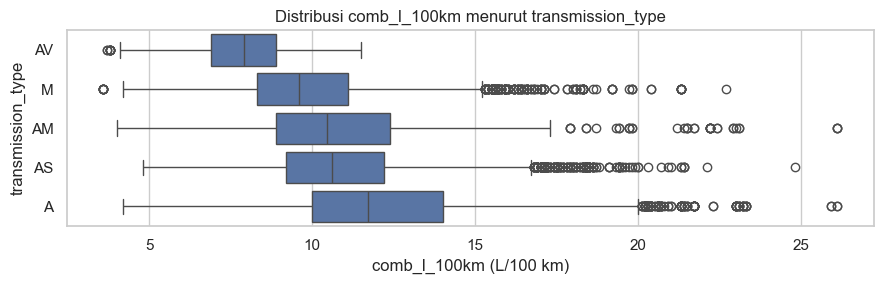

In [11]:
for col in cat_cols:
    order = df.groupby(col)['comb_l_100km'].median().sort_values().index
    plt.figure(figsize=(9, max(3.0, 0.34 * len(order))))
    sns.boxplot(data=df, y=col, x='comb_l_100km', order=order, orient='h')
    plt.title(f'Distribusi comb_l_100km menurut {col}')
    plt.xlabel('comb_l_100km (L/100 km)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**Interpretasi boxplot**:
- Ketiga faktor kategorikal menunjukkan pergeseran median yang sistematis antar kategori.
- Jenis bahan bakar Diesel paling hemat, sedangkan Ethanol (E85) dan Natural Gas paling boros.
- Kelas kendaraan menanjak dari sedan kecil ke van dan pickup.
- Tipe transmisi memperlihatkan perbedaan yang lebih landai namun sistematis antar lima tipe.

### 8. Matriks Korelasi Pearson

Korelasi Pearson mengukur kekuatan hubungan linear antar variabel numerik. Variabel kategorikal tidak disertakan di sini karena korelasi hanya bermakna untuk besaran numerik.

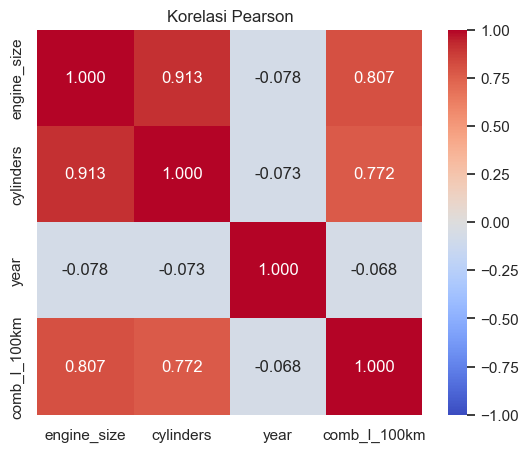

,engine_size,cylinders,year,comb_l_100km
engine_size,1.0000,0.9134,-0.0777,0.8073
cylinders,0.9134,1.0000,-0.0725,0.7716
year,-0.0777,-0.0725,1.0000,-0.0679
comb_l_100km,0.8073,0.7716,-0.0679,1.0000


In [12]:
num_for_corr = ['engine_size', 'cylinders', 'year', target]
pearson = df[num_for_corr].corr(method='pearson')
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(pearson, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Korelasi Pearson')
plt.show()
pearson

In [13]:
pearson_p = pd.DataFrame(np.nan, index=num_for_corr, columns=num_for_corr)
for a in num_for_corr:
    for b in num_for_corr:
        if a != b:
            _, p = stats.pearsonr(df[a], df[b])
            pearson_p.loc[a, b] = p
print('p-value korelasi Pearson')
pearson_p

p-value korelasi Pearson


,engine_size,cylinders,year,comb_l_100km
engine_size,NaN,0.0000,0.0000,0.0000
cylinders,0.0000,NaN,0.0000,0.0000
year,0.0000,0.0000,NaN,0.0000
comb_l_100km,0.0000,0.0000,0.0000,NaN


**Korelasi linear antar variabel numerik**:
- `engine_size` (r ~ 0.81) dan `cylinders` (r ~ 0.77) memiliki korelasi positif dengan `comb_l_100km`.
- `year` hampir tidak berkorelasi dengan `comb_l_100km` (|r| < 0.07).
- `engine_size` dan `cylinders` memiliki korelasi positif yang sangat kuat (r ~ 0.91), menandakan multikolinearitas.
- `n_gears` tidak disertakan di matriks ini karena CVT diberi nilai 0 sebagai konvensi (bukan benar-benar tanpa gigi), sehingga korelasi mentahnya bisa menyesatkan. Pengaruh `n_gears` terhadap hasil dapaat ditinjau melalui `transmission_type` dan pada tahap pemodelan.

**Signifikansi statistik**:
- Semua p-value mendekati 0 akibat n ~ 22k; pada sampel sebesar ini hampir semua korelasi otomatis signifikan.

### 9. Matriks Korelasi Spearman

Korelasi Spearman mengukur hubungan monotonik tanpa mengasumsikan bentuk linear, sehingga berguna sebagai pembanding terhadap Pearson.

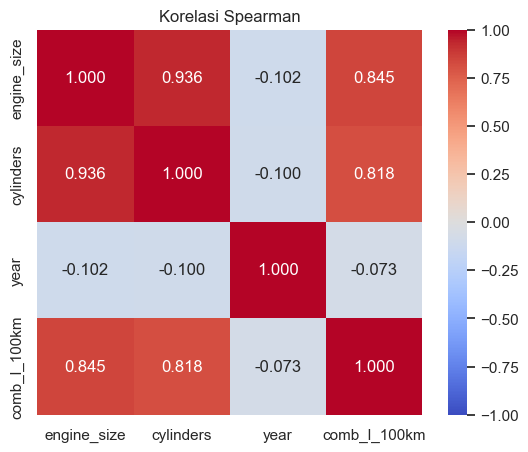

,engine_size,cylinders,year,comb_l_100km
engine_size,1.0000,0.9357,-0.1020,0.8449
cylinders,0.9357,1.0000,-0.0998,0.8176
year,-0.1020,-0.0998,1.0000,-0.0732
comb_l_100km,0.8449,0.8176,-0.0732,1.0000


In [14]:
spearman = df[num_for_corr].corr(method='spearman')
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(spearman, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Korelasi Spearman')
plt.show()
spearman

In [15]:
spearman_p = pd.DataFrame(np.nan, index=num_for_corr, columns=num_for_corr)
for a in num_for_corr:
    for b in num_for_corr:
        if a != b:
            _, p = stats.spearmanr(df[a], df[b])
            spearman_p.loc[a, b] = p
print('p-value korelasi Spearman')
spearman_p

p-value korelasi Spearman


,engine_size,cylinders,year,comb_l_100km
engine_size,NaN,0.0000,0.0000,0.0000
cylinders,0.0000,NaN,0.0000,0.0000
year,0.0000,0.0000,NaN,0.0000
comb_l_100km,0.0000,0.0000,0.0000,NaN


**Asosiasi monotonik**:
- `engine_size` dan `cylinders` menunjukkan asosiasi monotonik yang kuat dengan `comb_l_100km`, sedangkan `year` praktis tidak berasosiasi.

**Signifikansi statistik**:
- Semua p-value mendekati 0 akibat n ~ 22k; pada sampel sebesar ini hampir semua korelasi otomatis signifikan.

### 10. Selisih antar Korelasi |Spearman - Pearson|

Selisih mutlak antara korelasi Spearman dan Pearson dapat menunjukkan pasangan variabel yang hubungannya monotonik tetapi tidak linear. Selisih besar menandakan nonlinearitas, sedangkan kesenjangan kecil mengindikasikan hubungan cukup linear.

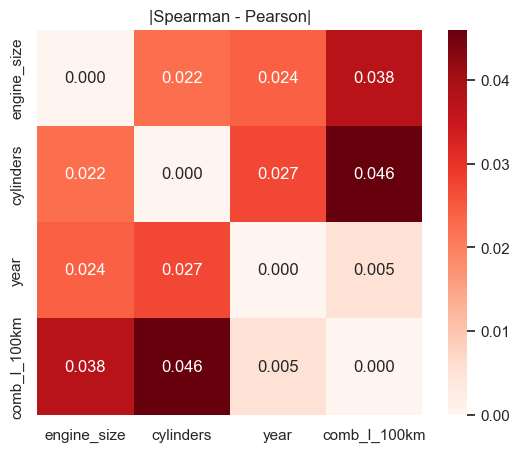

,engine_size,cylinders,year,comb_l_100km
engine_size,0.0000,0.0223,0.0242,0.0376
cylinders,0.0223,0.0000,0.0272,0.0460
year,0.0242,0.0272,0.0000,0.0053
comb_l_100km,0.0376,0.0460,0.0053,0.0000


In [16]:
gap = (spearman - pearson).abs()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(gap, annot=True, fmt='.3f', cmap='Reds', vmin=0, ax=ax, square=True)
ax.set_title('|Spearman - Pearson|')
plt.show()
gap

**Pembacaan selisih**:
- Seluruh nilai berada di bawah ~0.05, jadi hubungan antar variabel numerik praktis sudah linear.
- Tidak ada pasangan variabel yang punya selisih besar. Seandainya ada, itu menandakan hubungan monotonik tetapi tidak linear yang biasanya ditangani lewat regresi polinomial. 

In [17]:
df

,engine_size,cylinders,year,fuel,vehicle_class,comb_l_100km,transmission_type,n_gears
0,1.6000,4,2000,Regular gasoline,COMPACT,8.1000,A,4
1,1.6000,4,2000,Regular gasoline,COMPACT,7.6000,M,5
2,3.2000,6,2000,Premium gasoline,MID SIZE,10.0000,AS,5
3,3.5000,6,2000,Premium gasoline,MID SIZE,11.5000,A,4
4,1.8000,4,2000,Regular gasoline,SUBCOMPACT,8.6000,A,4
...,...,...,...,...,...,...,...,...
22550,2.0000,4,2022,Premium gasoline,SUV SMALL,9.4000,AS,8
22551,2.0000,4,2022,Premium gasoline,SUV SMALL,9.4000,AS,8
22552,2.0000,4,2022,Premium gasoline,SUV SMALL,9.9000,AS,8
22553,2.0000,4,2022,Premium gasoline,SUV STANDARD,10.1000,AS,8


## Seleksi Fitur

### 11. Penetapan Himpunan Fitur

**Keputusan himpunan fitur (berdasarkan temuan Fase 1)**:
- `engine_size` dan `cylinders`: keduanya dipertahankan. Masing-masing berkorelasi kuat dengan konsumsi (Pearson ~0.81 dan ~0.77), dan karena tidak redundan sempurna (r ~0.91, bukan 1) `cylinders` masih bisa menyumbang kontribusi dalam prediksi diluar `engine_size`. Kolinieritas yang tinggi membengkakkan standard error sehingga koefisien tidak bisa ditafsirkan sendiri-sendiri, tetapi tidak menurunkan daya prediksi selama korelasi antar-keduanya tetap berlaku pada data baru.
- `year`: dibuang. Korelasi marginalnya dengan konsumsi mendekati nol (|r| < 0.07), praktis tidak menyumbang daya prediksi.
- `n_gears`: dipertahankan; boxplot menunjukkan transmisi berkaitan dengan konsumsi (CVT = 0 sesuai konvensi).
- `fuel`, `vehicle_class`, `transmission_type`: dipertahankan karena boxplot memperlihatkan pergeseran median yang sistematis antar kategori; akan di-one-hot pada langkah berikutnya.

Kolinieritas `engine_size`-`cylinders` sudah cukup terbaca dari matriks korelasi Pearson, sehingga tidak diperlukan diagnostik tambahan.

In [18]:
# Buang `year` (korelasi ~0 dengan target); pertahankan sisanya
df = df.drop(columns='year')
num_cols = ['engine_size', 'cylinders', 'n_gears']
features = num_cols + cat_cols

print('Fitur final yang dipertahankan:')
print('  numerik     :', num_cols)
print('  kategorikal :', cat_cols)
print('  dibuang     : year')
print('  target      :', target)
df.head()

Fitur final yang dipertahankan:
  numerik     : ['engine_size', 'cylinders', 'n_gears']
  kategorikal : ['fuel', 'vehicle_class', 'transmission_type']
  dibuang     : year
  target      : comb_l_100km


,engine_size,cylinders,fuel,vehicle_class,comb_l_100km,transmission_type,n_gears
0,1.6000,4,Regular gasoline,COMPACT,8.1000,A,4
1,1.6000,4,Regular gasoline,COMPACT,7.6000,M,5
2,3.2000,6,Premium gasoline,MID SIZE,10.0000,AS,5
3,3.5000,6,Premium gasoline,MID SIZE,11.5000,A,4
4,1.8000,4,Regular gasoline,SUBCOMPACT,8.6000,A,4


### 12. One-Hot Encoding

Variabel kategorikal diubah menjadi kolom indikator 0/1. Untuk faktor dengan k kategori dibuat k-1 kolom, menyisakan satu kategori sebagai referensi untuk menghindari dummy variable trap (kolinieritas sempurna dengan konstanta).

In [19]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
dummy_cols = [c for c in df_encoded.columns if c.startswith(tuple(p + '_' for p in cat_cols))]
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)
feature_cols = num_cols + dummy_cols

print('Dimensi sebelum encoding :', df.shape)
print('Dimensi sesudah encoding :', df_encoded.shape)
print('Jumlah kolom dummy       :', len(dummy_cols))
print('Total fitur prediktor    :', len(feature_cols))
print()
for col in cat_cols:
    print(f'Kategori referensi {col:18s}: {sorted(df[col].unique())[0]}')
df_encoded.head()

Dimensi sebelum encoding : (22555, 7)
Dimensi sesudah encoding : (22555, 28)
Jumlah kolom dummy       : 24
Total fitur prediktor    : 27

Kategori referensi fuel              : Diesel
Kategori referensi vehicle_class     : COMPACT
Kategori referensi transmission_type : A


,engine_size,cylinders,comb_l_100km,n_gears,fuel_Ethanol (E85),fuel_Natural Gas,fuel_Premium gasoline,fuel_Regular gasoline,vehicle_class_FULL SIZE,vehicle_class_MID SIZE,...,vehicle_class_SUV,vehicle_class_SUV SMALL,vehicle_class_SUV STANDARD,vehicle_class_TWO SEATER,vehicle_class_VAN CARGO,vehicle_class_VAN PASSENGER,transmission_type_AM,transmission_type_AS,transmission_type_AV,transmission_type_M
0,1.6000,4,8.1000,4,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1.6000,4,7.6000,5,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,3.2000,6,10.0000,5,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,3.5000,6,11.5000,4,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1.8000,4,8.6000,4,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


**Hasil encoding**:
- Tiap faktor kategorikal terurai menjadi kolom 0/1; kategori referensi (alfabetis pertama) menjadi basis perbandingan koefisien nanti.
- Prediktor akhir terdiri dari fitur numerik (termasuk `n_gears`) ditambah seluruh kolom dummy.

### 13. Train dan Test Split

Matriks fitur yang sudah di-encode dibagi 80/20 dengan random state 1. Subset test ditahan dan hanya dipakai untuk menilai generalisasi pada fase akhir.

In [20]:
X_full = df_encoded[feature_cols].copy()
y_full = df_encoded[target].copy()
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=RNG)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (18044, 27) | Test: (4511, 27)


## Model Fitting dan Training

### 14. Spesifikasi dan Pelatihan Model

Model regresi linear berganda yang dilatih, dalam bentuk umum:

$$y_i = \beta_0 + \sum_{j=1}^{p} \beta_j\,x_{ij} + \varepsilon_i$$

Secara eksplisit untuk himpunan fitur kita ($p = 27$):

$$\widehat{y} = \beta_0 + \beta_1\,x_{\text{engine\_size}} + \beta_2\,x_{\text{cylinders}} + \beta_3\,x_{\text{n\_gears}} + \sum_{k=1}^{4} \gamma_k F_k + \sum_{l=1}^{16} \delta_l C_l + \sum_{m=1}^{4} \theta_m T_m + \varepsilon$$

dengan:
- $y$ = `comb_l_100km` (konsumsi gabungan, L/100 km)
- $F_k,\ C_l,\ T_m$ = kolom dummy 0/1 hasil one-hot untuk `fuel` (4 dummy), `vehicle_class` (16), dan `transmission_type` (4)
- $\beta_0$ = intercept, mewakili kategori referensi (fuel = Diesel, vehicle_class = COMPACT, transmission_type = A) saat seluruh prediktor numerik bernilai nol
- $\varepsilon$ = error

Koefisien diestimasi dengan OLS, yaitu meminimalkan jumlah kuadrat residual:

$$\hat{\beta} = \arg\min_{\beta} \sum_{i=1}^{n} \bigl(y_i - \widehat{y}_i\bigr)^2$$

Kita menambahkan kolom konstanta lalu memfit OLS pada data latih; matriks uji disiapkan dengan kolom yang sama untuk evaluasi pada fase akhir.

In [21]:
X_train_c = sm.add_constant(X_train).astype(float)
X_test_c = sm.add_constant(X_test, has_constant='add').astype(float)

model = sm.OLS(y_train, X_train_c).fit()

print(f'Observasi (train)  : {int(model.nobs)}')
print(f'Jumlah parameter   : {int(model.df_model) + 1}')
print(f'R-squared (train)  : {model.rsquared:.4f}')
print(f'Adj. R-squared     : {model.rsquared_adj:.4f}')
print(f'F-statistic        : {model.fvalue:,.1f}  (p = {model.f_pvalue:.3e})')

Observasi (train)  : 18044
Jumlah parameter   : 28
R-squared (train)  : 0.8342
Adj. R-squared     : 0.8339
F-statistic        : 3,356.1  (p = 0.000e+00)


**Bacaan awal**:
- R-squared menunjukkan proporsi dari data yang dapat dijelaskan oleh model model.
- F-statistic menguji H0 bahwa seluruh koefisien selain konstanta bernilai nol. p-value yang sangat kecil (p ~ 0) menolak hipotesa tersebut, menandakan koefisien regresi memiliki makna signifikan terhadap hasil prediksi.

**Performa pada train dan test**

Model yang sudah dilatih dijalankan pada subset latih dan subset uji untuk menilai generalisasi, memakai tiga metrik:

$$R^2 = 1 - \frac{\sum_i (y_i - \widehat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}, \qquad \text{RMSE} = \sqrt{\tfrac{1}{n}\sum_i (y_i - \widehat{y}_i)^2}, \qquad \text{MAE} = \tfrac{1}{n}\sum_i \lvert y_i - \widehat{y}_i \rvert$$

RMSE dan MAE berada dalam satuan asli respons (L/100 km).

In [22]:
def metrics(y_true, y_pred):
    return {
        'R^2': r2_score(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': mean_absolute_error(y_true, y_pred),
    }

train_pred = model.predict(X_train_c)
test_pred = model.predict(X_test_c)
perf = pd.DataFrame({'train': metrics(y_train, train_pred), 'test': metrics(y_test, test_pred)})
perf['selisih (train - test)'] = perf['train'] - perf['test']
perf

,train,test,selisih (train - test)
R^2,0.8342,0.8365,-0.0023
RMSE,1.1857,1.1757,0.0101
MAE,0.8962,0.8941,0.0020


**Interpretasi Train vs. Test**:
- Nilai R-squared, RMSE, dan MAE train dan test berdekatan, menandakan model tidak overfit.
- RMSE dan menunjukkan rata-rata simpangan prediksi yang tipikal untuk ekspektasi umum dalam satuan L/100 km

### 15. Interpretasi Koefisien

Cara membaca koefisien model regresi linear berganda:

$$\frac{\partial \widehat{y}}{\partial x_j} = \beta_j \quad (\text{numerik}), \qquad \widehat{y}(\text{kategori } k) - \widehat{y}(\text{referensi}) = \gamma_k \quad (\text{dummy})$$

- Prediktor numerik: $\beta_j$ adalah perubahan prediksi `comb_l_100km` untuk kenaikan satu satuan $x_j$, dengan menahan prediktor lain tetap (ceteris paribus).
- Prediktor kategorikal: $\gamma_k$ adalah selisih rata-rata `comb_l_100km` kategori $k$ terhadap kategori referensi, pada kondisi lain yang sama.
- Intercept $\beta_0$ mewakili kategori referensi (Diesel, COMPACT, transmisi A) saat semua prediktor numerik bernilai nol; nilai ini berada di luar rentang data sehingga tidak ditafsirkan secara harfiah.

In [23]:
coef = model.params

def show(label, keys):
    print(label)
    for k in keys:
        print(f'  {k:38s} = {coef[k]:+.4f}')
    print()

show('Intercept dan prediktor numerik:', ['const'] + num_cols)
show('Bahan bakar / fuel (vs Diesel):',
     sorted([k for k in coef.index if k.startswith('fuel_')], key=lambda k: -coef[k]))
show('Tipe transmisi (vs A / otomatis):',
     sorted([k for k in coef.index if k.startswith('transmission_type_')], key=lambda k: coef[k]))
show('Kelas kendaraan (vs COMPACT):',
     sorted([k for k in coef.index if k.startswith('vehicle_class_')], key=lambda k: coef[k]))

Intercept dan prediktor numerik:
  const                                  = +3.1407
  engine_size                            = +0.6438
  cylinders                              = +0.5740
  n_gears                                = -0.0518

Bahan bakar / fuel (vs Diesel):
  fuel_Ethanol (E85)                     = +5.4887
  fuel_Natural Gas                       = +3.7854
  fuel_Premium gasoline                  = +2.0951
  fuel_Regular gasoline                  = +1.4221

Tipe transmisi (vs A / otomatis):
  transmission_type_AV                   = -1.6222
  transmission_type_AS                   = +0.1310
  transmission_type_M                    = +0.1623
  transmission_type_AM                   = +0.4672

Kelas kendaraan (vs COMPACT):
  vehicle_class_MINICOMPACT              = -0.1952
  vehicle_class_MID SIZE                 = +0.0016
  vehicle_class_FULL SIZE                = +0.0155
  vehicle_class_SUBCOMPACT               = +0.0939
  vehicle_class_STATION WAGON SMALL      = +0.3136
 

**Pembacaan koefisien**:
- `engine_size` (+0.64) dan `cylinders` (+0.57) sama-sama positif: mesin lebih besar dan silinder lebih banyak menaikkan konsumsi. Karena keduanya kolinier (r ~0.91), nilainya tidak ditafsirkan sendiri-sendiri; yang bermakna adalah pengaruh gabungan keduanya sebagai ukuran/kapasitas mesin.
- `n_gears` (-0.05): tiap tambahan gigi sedikit menurunkan konsumsi, konsisten dengan transmisi berasio lebih banyak yang lebih efisien.
- Bahan bakar (vs Diesel): semua koefisien positif, jadi Diesel paling hemat. Ethanol (E85) menggeser konsumsi paling besar (+5.49), disusul Natural Gas (+3.79), Premium (+2.10), dan Regular (+1.42) — sejalan dengan densitas energi etanol/gas yang lebih rendah sehingga butuh volume lebih banyak per 100 km.
- Tipe transmisi (vs A/otomatis): CVT (AV) menonjol paling hemat (-1.62), sedangkan AM (+0.47), M (+0.16), dan AS (+0.13) hanya berbeda tipis.
- Kelas kendaraan (vs COMPACT): membentuk gradien jelas dari mobil kecil (minicompact -0.20; subcompact dan mid-size mendekati nol) hingga kendaraan besar yang jauh lebih boros — VAN PASSENGER (+3.92), VAN CARGO (+2.62), pikap (~+2.0), dan SUV (+1.37 sampai +1.75).

## Validasi Asumsi

Estimasi OLS dan inferensinya bersandar pada beberapa asumsi tentang galat $\varepsilon$:

$$\mathbb{E}[\varepsilon_i \mid X] = 0 \;\; (\text{linearitas}), \qquad \operatorname{Var}(\varepsilon_i) = \sigma^2 \;\; (\text{homoskedastisitas}),$$

$$\operatorname{Cov}(\varepsilon_i, \varepsilon_j) = 0,\; i \neq j \;\; (\text{independensi}), \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2) \;\; (\text{normalitas, untuk inferensi}).$$

Kita menguji homoskedastisitas dan normalitas, baik secara formal maupun lewat diagnostik visual. Independensi galat tidak diuji secara formal: data bersifat cross-sectional sehingga urutan baris tidak bermakna dan uji autokorelasi (mis. Durbin-Watson) tidak relevan; independensi disandarkan pada desain pengambilan sampel. Catatan penting: pada n besar (~18k) uji formal sangat sensitif sehingga hampir selalu menolak meski penyimpangannya kecil, sehingga diagnostik visual menjadi penilaian yang menentukan dan teorema limit pusat menjaga inferensi koefisien tetap valid secara aproksimasi.

### 16. Uji Formal Asumsi

- Breusch-Pagan (homoskedastisitas): $H_0:\operatorname{Var}(\varepsilon_i)=\sigma^2$ konstan, vs $H_1$: varians bergantung pada prediktor. Tolak $H_0$ bila $p < 0.05$.
- Jarque-Bera (normalitas): $H_0$: residual normal (skewness $=0$, kurtosis $=3$), vs $H_1$: tidak normal.

In [24]:
resid = model.resid
fitted = model.fittedvalues

bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_train_c)
jb_stat, jb_p, skew, kurt = jarque_bera(resid)

print('Breusch-Pagan (homoskedastisitas):')
print(f'  LM stat = {bp_stat:,.1f}   p-value = {bp_p:.3g}   -> {"heteroskedastik" if bp_p < 0.05 else "homoskedastik"}')
print('\nJarque-Bera (normalitas):')
print(f'  JB stat = {jb_stat:,.1f}   p-value = {jb_p:.3g}   (skewness={skew:.2f}, kurtosis={kurt:.2f})   -> {"tolak normal" if jb_p < 0.05 else "gagal tolak normal"}')

Breusch-Pagan (homoskedastisitas):
  LM stat = 1,491.5   p-value = 6.38e-298   -> heteroskedastik

Jarque-Bera (normalitas):
  JB stat = 3,995.8   p-value = 0   (skewness=0.42, kurtosis=5.14)   -> tolak normal


**Hasil uji formal**:
- Breusch-Pagan menolak homoskedastisitas (p mendekati 0): residual heteroskedastik. Pada n sebesar ini, heteroskedastisitas hampir pasti muncul, namun ini hanya berdampak ke standard error dan dapat ditangani dengan standard error robust (HC3) bila inferensi presisi diperlukan.
- Jarque-Bera menolak normalitas (p mendekati 0): residual tidak persis Gaussian (skewness/kurtosis menyimpang), cukup wajar untuk data yang sedikit condong. Dengan n besar, *central limit theorem* menjaga inferensi koefisien tetap valid.

### 17. Diagnostik Visual

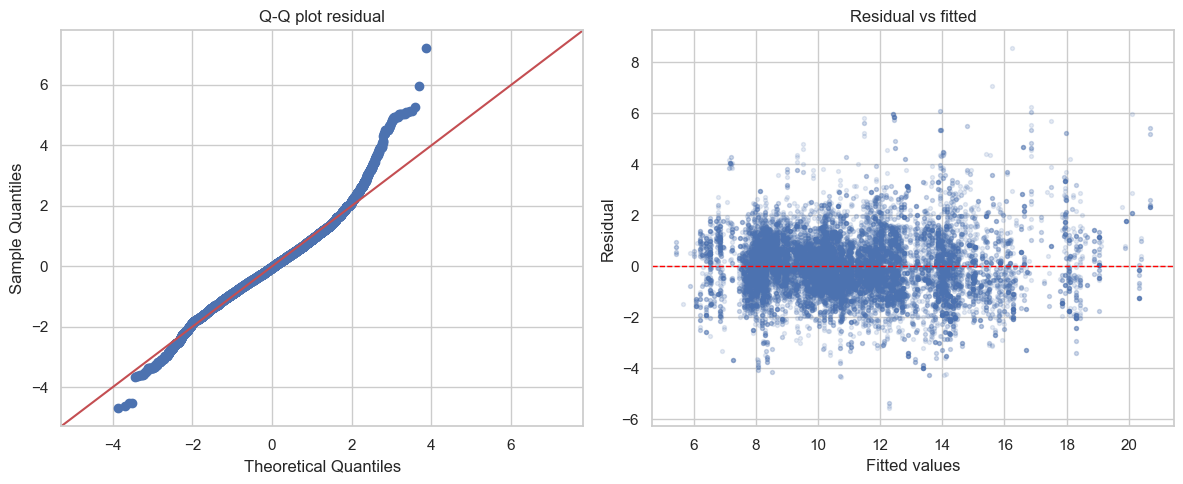

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sm.qqplot(resid, line='45', fit=True, ax=axes[0])
axes[0].set_title('Q-Q plot residual')
axes[1].scatter(fitted, resid, alpha=0.15, s=8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual vs fitted')
fig.tight_layout()
plt.show()

**Diagnostik visual**:
- Q-Q plot: bagian tengah mengikuti garis 45 derajat dengan penyimpangan terkonsentrasi di ekor, ini merupakan pola yang cukup umum untuk variabel respons yang sedikit skewed dan masih dapat diterima.
- Residual vs fitted: pita di sekitar nol; bentuk melebar seperti corong menandakan heteroskedastisitas (konsisten dengan Breusch-Pagan), sedangkan lengkungan sistematis akan menandakan ketidaklinieran. Spesifikasi linear tampak memadai.

Pelanggaran normalitas dan homoskedastisitas bersifat formal (akibat n besar) dan tidak fatal untuk tujuan prediktif.

## Refinement dan Interpretasi

### 18. Kontribusi `cylinders` (Ablasi)

`engine_size` dan `cylinders` sangat kolinier (r ~0.91), sehingga koefisiennya sukar ditafsirkan sendiri-sendiri. Namun untuk model prediktif pertanyaannya bukan itu, melainkan: apakah `cylinders` menambah daya prediksi di atas `engine_size`? Kita jawab dengan membandingkan model lengkap dengan model tanpa `cylinders` pada data uji.

In [26]:
# Apakah cylinders menambah daya prediksi di atas engine_size (keduanya kolinier r~0.91)?
feat_no_cyl = [c for c in feature_cols if c != 'cylinders']
Xtr_nc = sm.add_constant(X_train[feat_no_cyl]).astype(float)
Xte_nc = sm.add_constant(X_test[feat_no_cyl], has_constant='add').astype(float)
m_no_cyl = sm.OLS(y_train, Xtr_nc).fit()

r2t_full = r2_score(y_test, model.predict(X_test_c))
r2t_nc = r2_score(y_test, m_no_cyl.predict(Xte_nc))
abla = pd.DataFrame(
    {'R2_train': [model.rsquared, m_no_cyl.rsquared], 'R2_test': [r2t_full, r2t_nc]},
    index=['dengan cylinders', 'tanpa cylinders'],
)
print(f'Kontribusi cylinders pada R^2 uji: {r2t_full - r2t_nc:+.4f}')
abla.round(4)

Kontribusi cylinders pada R^2 uji: +0.0197


,R2_train,R2_test
dengan cylinders,0.8342,0.8365
tanpa cylinders,0.8164,0.8168


**Hasil ablasi**:
- Membuang `cylinders` menurunkan R-squared uji sekitar 0.02. Penurunan yang konsisten pada data uji (bukan hanya latih) menandakan informasi itu nyata, bukan overfitting.
- Jadi `cylinders` menyumbang daya prediksi di luar `engine_size`: kolinier bukan berarti redundan. Inilah alasan empiris mempertahankan keduanya, dengan koefisien ditafsirkan bersama.